{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Évaluation des performances des modèles :
                  Modèle  Précision    Rappel  F-mesure
0  Régression Logistique   0.931694  0.874359  0.902116
1      Arbre de Décision   0.915119  0.884615  0.899609
2                    SVM   0.950820  0.892308  0.920635


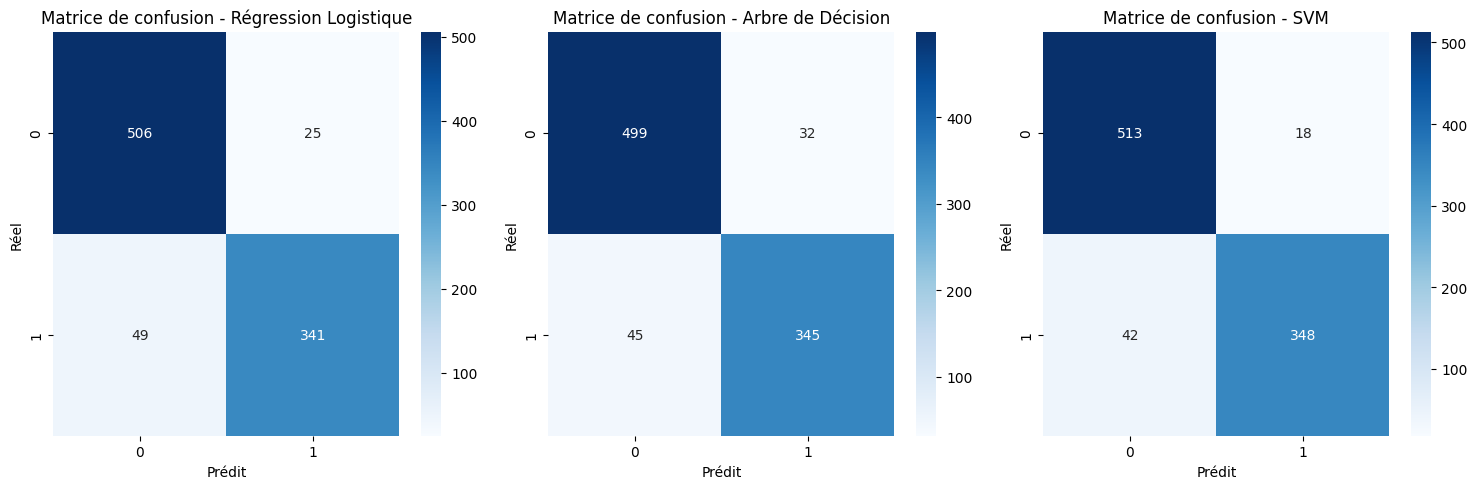


Importance des caractéristiques (Régression Logistique) :
                            Coefficient  Importance
word_freq_george              -4.498968    4.498968
word_freq_hp                  -2.775573    2.775573
word_freq_cs                  -1.539990    1.539990
word_freq_project             -1.417425    1.417425
word_freq_meeting             -1.268478    1.268478
word_freq_edu                 -1.249606    1.249606
char_freq_$                    1.229558    1.229558
word_freq_lab                 -1.031946    1.031946
word_freq_conference          -1.030036    1.030036
word_freq_000                  0.980695    0.980695
char_freq_#                    0.929066    0.929066
word_freq_remove               0.917685    0.917685
word_freq_hpl                 -0.858006    0.858006
word_freq_3d                   0.855120    0.855120
word_freq_free                 0.850529    0.850529
capital_run_length_longest     0.848816    0.848816
word_freq_85                  -0.756353    0.756353
word_

In [ ]:
!pip install ucimlrepo
import pandas as pd
url='https://archive.ics.uci.edu/dataset/94/spambase'
from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


# fetch dataset
spambase = fetch_ucirepo(id=94)

# data (as pandas dataframes)
X = spambase.data.features
Y = spambase.data.targets

# metadata
print(spambase.metadata)

# variable information
print(spambase.variables)
X= X.dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled,Y, test_size=0.2, random_state=42)

# 3. Modélisation
# Régression Logistique
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, Y_train)
log_predictions = log_model.predict(X_test)

# Arbre de Décision
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, Y_train)
tree_predictions = tree_model.predict(X_test)

#SVM
svm_model = SVC()
svm_model.fit(X_train, Y_train)
svm_predictions = svm_model.predict(X_test)

# 4. Évaluation des Modèles
results = []
for model, predictions, name in zip(
    [log_model, tree_model, svm_model],
    [log_predictions, tree_predictions, svm_predictions],
    ['Régression Logistique', 'Arbre de Décision', 'SVM']
):
    report = classification_report(Y_test, predictions, output_dict=True)
    results.append({
        'Modèle': name,
        'Précision': report['1']['precision'],
        'Rappel': report['1']['recall'],
        'F-mesure': report['1']['f1-score']
    })

# Conversion de la liste en DataFrame
results_df = pd.DataFrame (results)
# Affichage des résultats
print("Évaluation des performances des modèles :")
print(results_df)

plt.figure(figsize=(15, 5))

# Logistic Regression
plt.subplot(1, 3, 1)
sns.heatmap(confusion_matrix(Y_test, log_predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Régression Logistique')
plt.xlabel('Prédit')
plt.ylabel('Réel')

# Decision Tree
plt.subplot(1, 3, 2)
sns.heatmap(confusion_matrix(Y_test, tree_predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Arbre de Décision')
plt.xlabel('Prédit')
plt.ylabel('Réel')

# SVM
plt.subplot(1, 3, 3)
sns.heatmap(confusion_matrix(Y_test, svm_predictions), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - SVM')
plt.xlabel('Prédit')
plt.ylabel('Réel')

plt.tight_layout()
plt.show()

# Coefficients du modèle de régression logistique
if hasattr(log_model, 'coef_'):
    # transformer les coefficients en DataFrame
    coef_df = pd.DataFrame(log_model.coef_.T, index=X.columns, columns=['Coefficient'])
    # calculer l'importance absolue
    coef_df['Importance'] = coef_df['Coefficient'].abs()
    # trier par importance
    coef_df = coef_df.sort_values(by='Importance', ascending=False)
    print("\nImportance des caractéristiques (Régression Logistique) :")
    print(coef_df)

